# "THE PRICE IS RIGHT" Capstone Project:

In this module, we'll build a model that predicts how much something costs from a description, based on a scrape of Amazon data

## Order of play:

DAY 1: Data Curation

DAY 2: Data Pre-processing

DAY 3: Evaluation, Baselines, Traditional ML

DAY 4: Deep Learning and LLMs

DAY 5: Fine-tuning a Frontier Model

### DAY 1: Data Curation

Today we'll scrub our dataset and curate our data.

The dataset is here:
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

In [1]:
# Imports:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from sqlalchemy.util import counter
from tqdm.notebook import tqdm
import numpy as np
import random
from pricer.items import Item
from pricer.parser import parse
load_dotenv(override= True)

True

In [2]:
# Logging in to Hugging Face:
hf_token = os.getenv('HF_TOKEN')
login(token = hf_token, add_to_git_credential= True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


### Loading in Dataset:

In the next cell, we load in the dataset from huggingface.

If this gives you an error like "trust_remote_code is no longer supported", then please run this command in a new cell: `!pip install --upgrade datasets==3.6.0` and then restart the Kernel, and try again.

In [3]:
dataset= load_dataset('McAuley-Lab/Amazon-Reviews-2023',
                      'raw_meta_Appliances',
                      split= 'full',
                      trust_remote_code= True)

In [4]:
print(f'Number of Appliances: {len(dataset)}')

Number of Appliances: 94327


In [5]:
# Investigating a Particular Datapoint:
dataset[10]

{'main_category': 'Tools & Home Improvement',
 'title': 'WP67003405 67003405 Door Pivot Block - Compatible Kenmore KitchenAid Maytag Whirlpool Refrigerator - Replaces AP6010352 8208254 PS11743531 - Quick DIY Repair Solution',
 'average_rating': 4.1,
 'rating_number': 4,
 'features': ['WP67003405 Pivot Block For Vernicle Mullion Strip On Door - A high-quality exact equivalent for part numbers AP6010352, 67003405, 1025322, 12698403, 67003194, 8208254, and PS11743531.',
  'Compatibility with major brands - WP67003405 Door Guide is compatible with Whirlpool, Amana, Dacor, Gaggenau, Hardwick, Jenn-Air, Kenmore, KitchenAid, and Maytag.',
  "Quick DIY repair - WP67003405 Refrigerator Door Guide Pivot Block Replacement will help if your appliance door doesn't open or close. Wear work gloves to protect your hands during the repair process.",
  'Attentive support - If you are uncertain about whether the block fits your refrigerator, we will help. We generally put forth a valiant effort to guaran

In [6]:
# Most Expensive Item:

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint['price'])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The Most Expensive Item is: {max_item['title']} and it Costs: {max_price:,.2f}")

  0%|          | 0/94327 [00:00<?, ?it/s]

The Most Expensive Item is: TurboChef BULLET Rapid Cook Electric Microwave Convection Oven and it Costs: 21,095.62


In [7]:
# Loading in Item Objects if they have a Price Range $1-$1000 and Enough Details:
items = [parse(datapoint, 'Appliances') for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items)} items from {len(dataset)} datapoints")

  0%|          | 0/94327 [00:00<?, ?it/s]

There are 35307 items from 94327 datapoints


In [8]:
items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

In [9]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud 

### Plotting Distribution of Description Lengths and Prices:

In [10]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

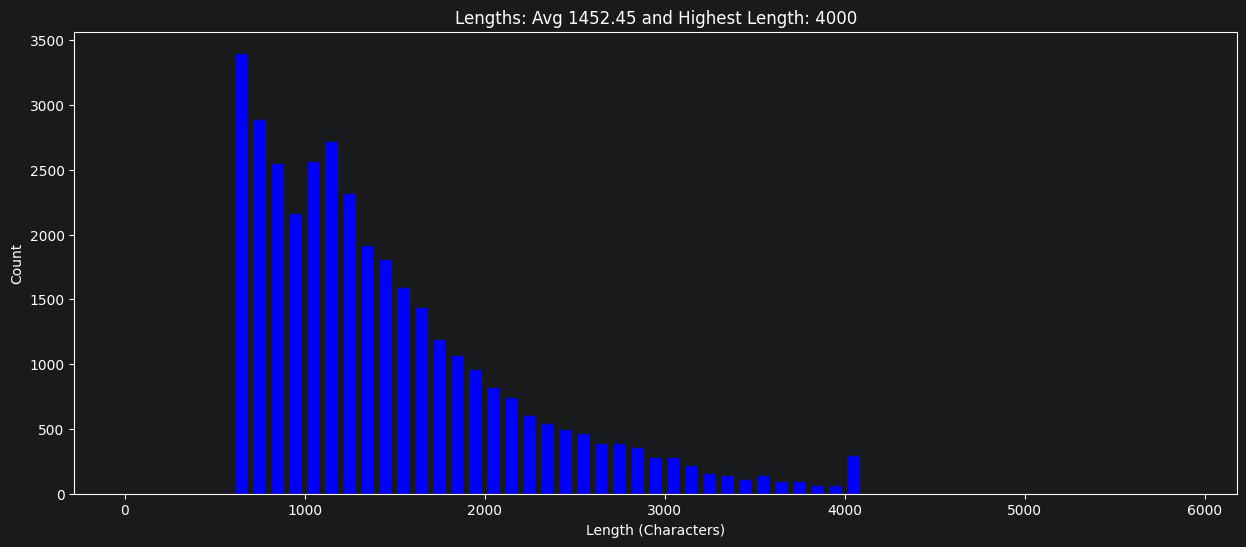

In [11]:
# Distribution of Description Lengths:
plt.figure(figsize= (15,6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):.2f} and Highest Length: {max(lengths)}")
plt.xlabel('Length (Characters)')
plt.ylabel('Count')
plt.hist(lengths, color= 'blue', bins= range(0, 6000, 100), rwidth= 0.7)
plt.show()

In [12]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12
['✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality.', '✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent.', '✅【WIDE 】--- These polyester filters are desig

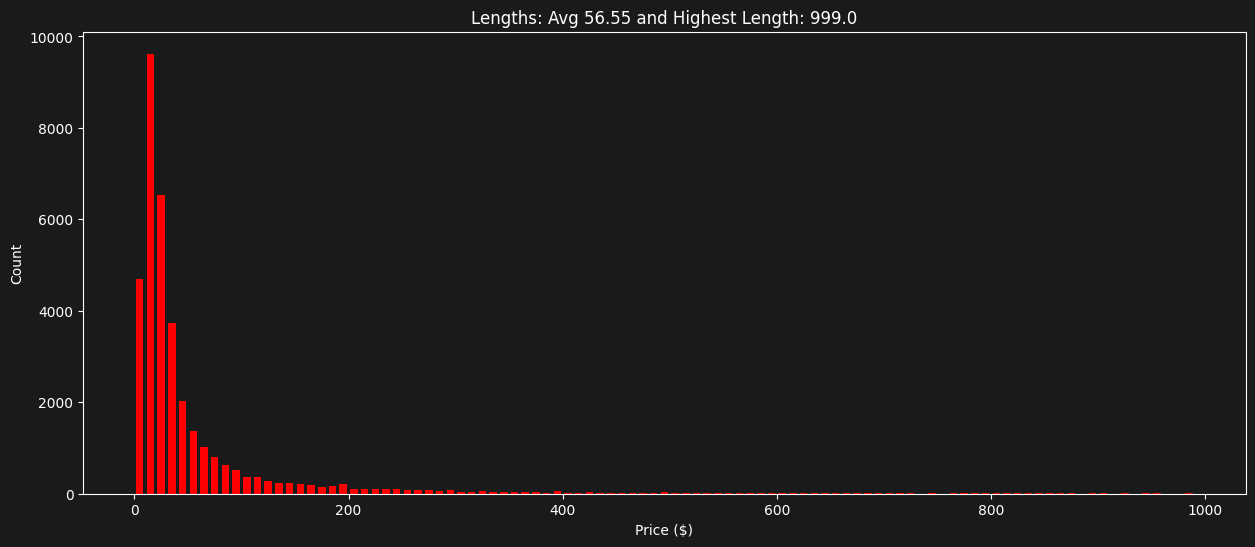

In [13]:
# Distribution of Prices:
plt.figure(figsize= (15,6))
plt.title(f"Lengths: Avg {sum(prices)/len(prices):.2f} and Highest Length: {max(prices)}")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, color= 'red', bins= range(0, 1000, 10), rwidth= 0.7)
plt.show()

In [14]:
max_price = max(prices)
max_price_item = items[prices.index(max_price)]
print(max_price_item.full)

EdgeStar  Full Size Dual Tap Kegerator with Digital Display - Black and Stainless Steel
['PLEASE NOTE: Part number  will be shown on the retail box and all needed items that comprise the  will be included within this same box; Freestanding operation only; Digital display; Adjustable temperature', 'Deep chill mode; Dispensing components included; Black cabinet & stainless steel door', 'Guard rail, drip tray, & casters included; Includes two (2) wire shelves for refrigerator use', 'Fits half-barrel, slim quarter, corny, and sixth barrel kegs; Dimensions (fridge only without casters or tower) 33 1/2" H x 23 5/8" W x 23 3/8" D', 'PLEASE NOTE: Delivery will be curbside, inside delivery is not available. A valid phone number is required for delivery purposes, please ensure the correct phone number is provided in your shipping information when placing this order.']
{"Manufacturer": "EdgeStar", "Item Weight": "79.4 pounds", "Product Dimensions": "23.38\"D x 23.63\"W x 33.5\"H", "Is Discontinue

### Loading in Different Categories of Items from Dataset:

In [15]:
from pricer.loaders import ItemLoader

dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

#### Skipping running the below code blocks as it takes hours to download the data:

```python
items = []

for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

print(f"A grand total of {len(items):,} items")
```

This block is the master controller for the data ingestion phase. It transforms a simple list of strings into a massive, unified dataset of hundreds of thousands of parsed Python objects.

1. items = [] * The Setup: Initializes an empty master list in memory. This will act as the final bucket holding every single product from every single category.

2. for dataset_name in dataset_names: * The Iterator: Loops through the predefined list of Amazon categories (e.g., "Automotive", "Appliances").

3. loader = ItemLoader(dataset_name) * Instantiation: For the current category in the loop, it creates a fresh instance of the ItemLoader class. It passes the category string so the class knows exactly which Hugging Face repository string to construct.

4. items.extend(loader.load()) * Execution & Flattening: This line does two massive things simultaneously:

    - First, it calls .load(), which triggers the Hugging Face download, spins up the multiprocessing CPU cores, parses the text, and returns a list of cleaned Item objects for that specific category.

    - Second, it uses Python's .extend() method. By using .extend(), Python cracks open the returned list and adds each item individually to the master list, maintaining a perfectly flat, 1-dimensional array of data (e.g., [auto_1, auto_2, elec_1, elec_2]).

Why this takes hours: Because the .load() function is blocking (synchronous), the loop pauses completely until "Automotive" is 100% downloaded and parsed before it even attempts to start downloading "Electronics".

```python
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")
```

This block removes duplicate products from the massive merged dataset. Instead of using a standard for loop, it uses an advanced list comprehension trick to process millions of items at C-level speeds.

1. random.seed(42) & random.shuffle(items):
    - Bias Prevention: When you have 5 identical items, a deduplication script naturally keeps the first one it sees and deletes the rest. If the dataset was downloaded alphabetically or by date, you might accidentally introduce a bias into your data. Shuffling the massive list first ensures that the single duplicate you keep is completely random. (seed(42) ensures that if you run this script tomorrow, it shuffles the list in the exact same way for reproducibility).

2. seen = set(): The Memory Bank: Initializes an empty Python set. Sets are mathematically optimized for incredibly fast lookups ($O(1)$ time complexity), making them much faster to check than standard lists.

3. items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]:
    - Short-Circuit Evaluation: This is the core engine. It checks every item (x) in the list using an or statement logic trap:
        - If the item is NEW: x.title in seen evaluates to False. Because it's an or statement, Python must check the right side. It executes seen.add(x.title). Because set.add() returns None in Python, the parentheses evaluate to (False or None) $\rightarrow$ None. The not keyword flips None to True, so the item is kept.
        - If the item is a DUPLICATE: x.title in seen evaluates to True. Python uses "short-circuiting"—because the left side is True, the whole or statement is True. It skips the right side entirely (seen.add is never run). The not keyword flips the True to False, and the item is discarded.

4. The Double Pass:
    - The code resets the memory bank (seen = set()) and runs the exact same logic trap again, but this time it checks the x.full attribute. This acts as a safety net to catch products that might have had slightly different titles but identical descriptions.

5. del seen:
    - Memory Management: Sets storing hundreds of thousands of text strings consume a massive amount of RAM. Deleting the seen variable immediately frees up system memory before moving on to the next heavy processing step.

```python
np.random.seed(42)

SIZE = 820_000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]
```

The Dataset is heavily biased because 80% of the products are cheap car parts or screws. This block uses NumPy to rig a "weighted lottery" that artificially forces the final dataset to be diverse and balanced.

1. p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9):

Min-Max Normalization: This takes every price in the dataset and mathematically squishes it onto a scale exactly between 0.0 and 1.0. (e.g., A $0.50 item becomes 0.0, a $500 item becomes 0.5, and a $1000 item becomes 1.0).
Note: The 1e-9 is a tiny microscopic fraction added to the denominator purely to prevent a "Divide by Zero" error if all items accidentally had the exact same price.

2. w = p**2:

The Price Boost: The code squares the normalized price to determine its "weight" (probability of being picked). When you square fractions (numbers between 0 and 1), they get smaller. However, 0.1 * 0.1 = 0.01 (a massive drop), while 0.9 * 0.9 = 0.81 (a small drop). This mathematical trick brutally penalizes cheap items, drastically increasing the odds that expensive items will be selected for the final AI training data.

3. w[...] *= 0.5 and w[...] *= 0.05:

The Category Penalty: Even with price balancing, there are simply too many Automotive and Tool products. This manually slashes the probability (weight) of a Tool being picked by 50%, and an Automotive part by 95%.

4. w = w / w.sum():

Probability Normalization: NumPy's random selection tool strictly requires that all probabilities in a list add up to exactly 1.0 (100%). This line divides every individual weight by the grand total of all weights, mathematically forcing the entire list to sum to 1.0.

5. idx = np.random.choice(len(items), size=SIZE, replace=False, p=w):

The Rigged Lottery: It tells NumPy: "Pick 820,000 random item index numbers (size=SIZE). Do not pick the same item twice (replace=False). But instead of a fair lottery, use my rigged probability weights (p=w)."

6. sample = [items[i] for i in idx]

The Final Extraction: It builds the final curated dataset by grabbing the exact Item objects that correspond to the winning lottery numbers.

### Downloading Curated Dataset given by Course instructor Ed Donner directly from Hugging Face:

In [16]:
from pricer.items import Item

train, val, test = Item.from_hub("ed-donner/items_raw_full")

# Combining to Visually Analyze whole dataset:
sample = train + val + test
print(f"Successfully loaded {len(sample):,} curated items!")

Successfully loaded 820,000 curated items!


In [17]:
sample[0]

<Schlage F59 AND 613 Andover Interior Knob with Deadbolt, Oil Rubbed Bronze (Interior Half Only) = $64.3>

In [18]:
sample[0].full

'Schlage F59 AND 613 Andover Interior Knob with Deadbolt, Oil Rubbed Bronze (Interior Half Only)\n[\'From the Manufacturer\', "When you have a Schlage handleset on your front door, you ensure your security as well as your peace of mind. After all, we\'re the leader in security devices, trusted for over 85 years. All Schlage handlesets are precision engineered, featuring 100% solid"]\n[\'Interior half only\', \'Requires F58 to complete handle set\', \'Non handed knob style\', \'4" minimum center to center door prep required for this two piece model.\', \'Lifetime Mechanical and Finish Warranty\']\n{"Material": "Metal", "Brand": "", "Color": "Oil Rubbed Bronze", "Exterior Finish": "Bronze", "Special Feature": "Easy to Install", "Age Range (Description)": "Adult", "Included Components": "Deadbolt, Knob", "Item Weight": "1.5 pounds", "Handle Material": "Bronze", "Package Type": "Standard Packaging", "Unit Count": "1.0 Count", "Number of Items": "1", "Manufacturer": "Schlage", "Product Dime

In [19]:
sample[0].price

64.3

### Visualizing Data:

#### Price Distribution:

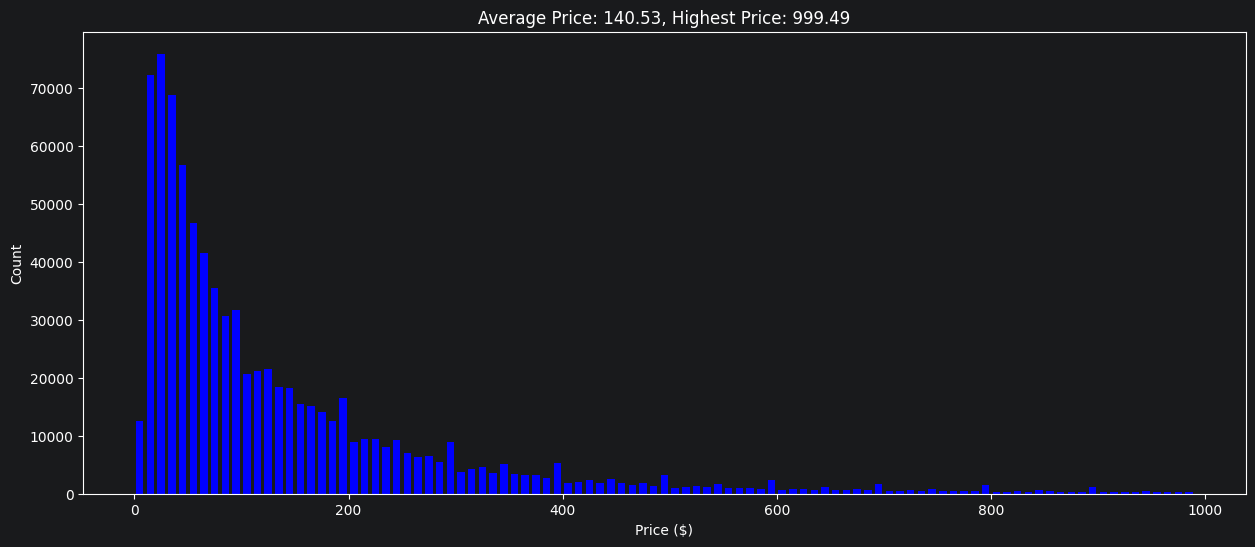

In [22]:
prices = [item.price for item in sample]

plt.figure(figsize= (15,6))
plt.hist(prices, rwidth= 0.7, color= 'blue', bins= range(0, 1000, 10))
plt.title(f"Average Price: {sum(prices)/len(prices):.2f}, Highest Price: {max(prices)}")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

#### Category wise Item Count:

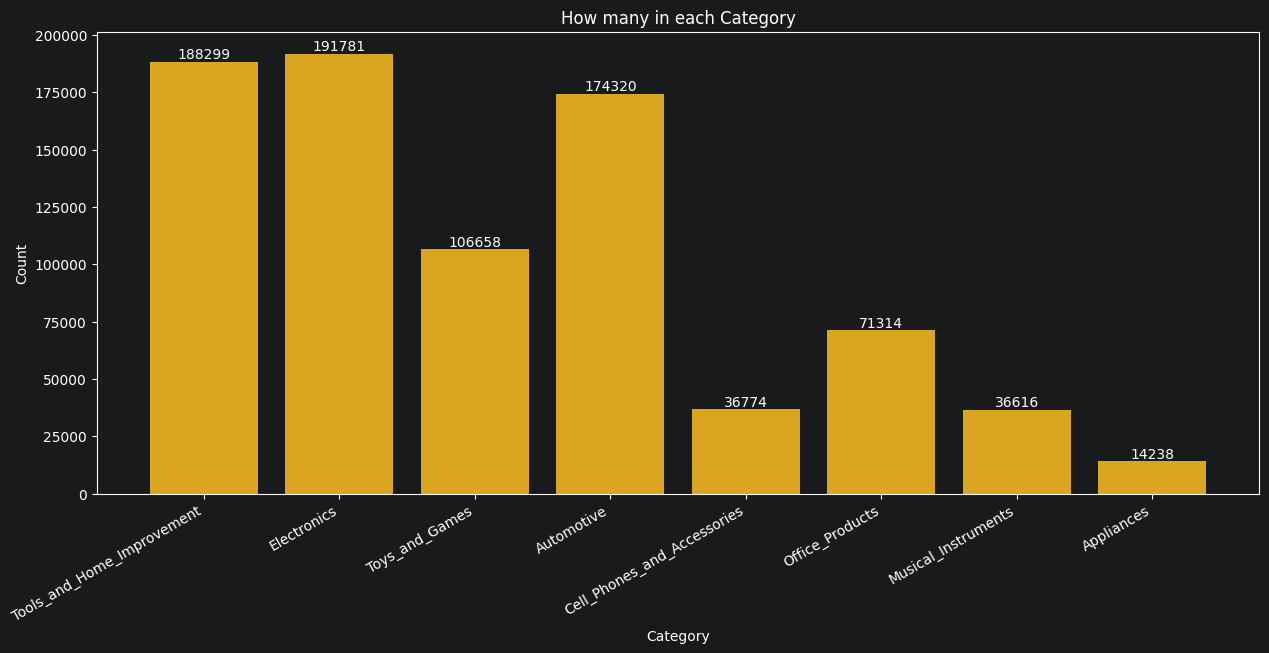

In [24]:
from collections import Counter
category_counts = Counter([item.category for item in sample])
categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize= (15,6))
plt.bar(categories, counts, color= 'goldenrod')
plt.title('How many in each Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation= 30, ha= 'right')

# Adding Value Label on Each Bar:
for i, v in enumerate(counts):
    plt.text(i, v, f"{v}", ha= 'center', va= 'bottom')
plt.show()

#### Price variance with Length of Description:

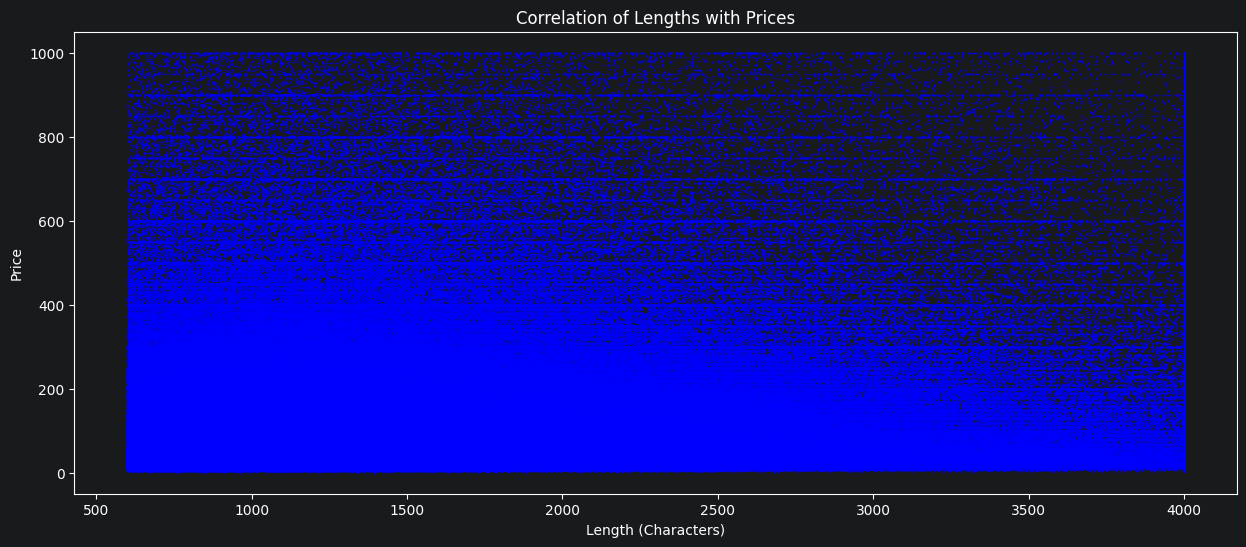

In [28]:
lengths = [len(item.full) for item in sample]
prices = [item.price for item in sample]

# Scatter Plot:
plt.figure(figsize= (15,6))
plt.scatter(lengths, prices, s= 0.2, color= 'blue')
plt.title('Correlation of Lengths with Prices')
plt.xlabel('Length (Characters)')
plt.ylabel('Price')
plt.show()

#### Price variance with Weight:

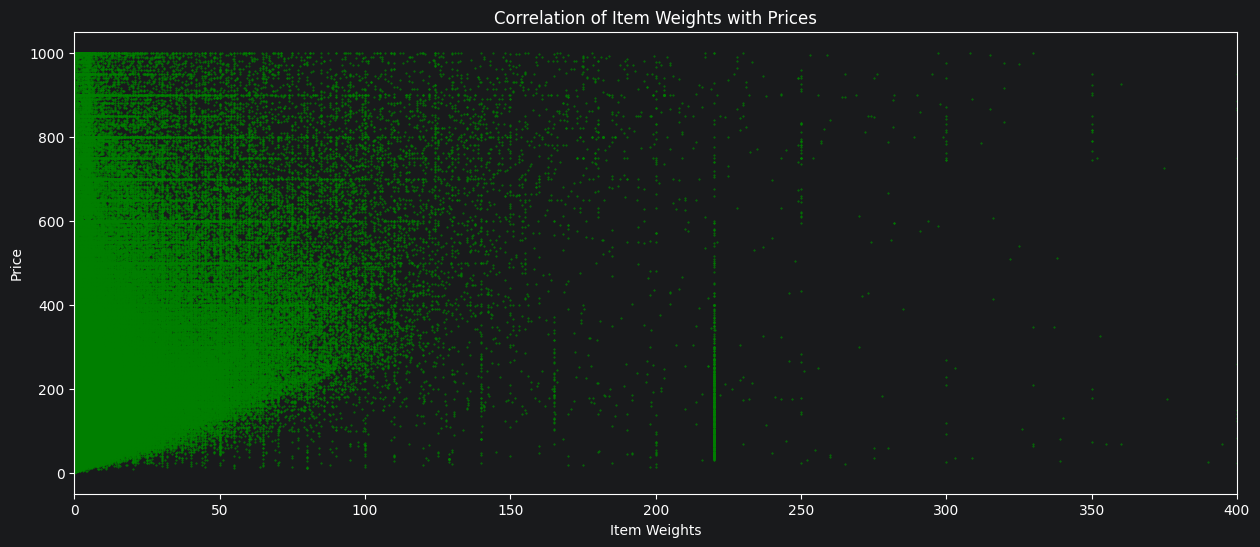

In [30]:
weights = [item.weight for item in sample]
prices = [item.price for item in sample]

# Scatter Plot:
plt.figure(figsize= (15,6))
plt.scatter(weights, prices, s= 0.2, color= 'green')
plt.title('Correlation of Item Weights with Prices')
plt.xlabel('Item Weights')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.show()